# 03 — Feature Engineering

This notebook defines the model’s feature set, specifying the numerical and categorical variables used and clearly separating the features from the target.

In [2]:
import os
import sys
import pandas as pd
import numpy as np

sys.path.append(os.path.abspath(".."))
sys.path.append(os.path.abspath("../src"))

from pathlib import Path
from src.features import (
    add_phase, add_study_date_features, add_days_since_first_visit,
    add_age_band, add_visit_number, add_target_numeric,
    add_prev_airq_mean, add_prev_attacks
)
from src.visualization import (
    plot_phase_distribution, plot_season_distribution,
    plot_airq_by_season, plot_visits_distribution
)

In [3]:
# Load dataset
df = pd.read_csv("../data/processed/clean_migraine.csv")

In [4]:
# Apply feature engineering
df = add_phase(df)
df = add_study_date_features(df)
df = add_days_since_first_visit(df)
df = add_age_band(df)
df = add_visit_number(df)
df = add_target_numeric(df)
df = add_prev_airq_mean(df)
df = add_prev_attacks(df)

# Show preview
df.head()

,rownames,id,time,dos,hatype,age,airq,medication,headache,sex,...,phase,study_date,study_month,study_season,days_since_first_visit,age_band,visit_number,target_num,airq_prev_mean,prev_attacks
0,1,1,-11,753,Aura,30,9.0,continuing,yes,female,...,No treatment,1999-01-24,1,winter,0,18-30,1,1,NaN,0.0
1,2,1,-10,754,Aura,30,7.0,continuing,yes,female,...,No treatment,1999-01-25,1,winter,1,18-30,2,1,9.000000,1.0
2,3,1,-9,755,Aura,30,10.0,continuing,yes,female,...,No treatment,1999-01-26,1,winter,2,18-30,3,1,8.000000,2.0
3,4,1,-8,756,Aura,30,13.0,continuing,yes,female,...,No treatment,1999-01-27,1,winter,3,18-30,4,1,8.666667,3.0
4,5,1,-7,757,Aura,30,18.0,continuing,yes,female,...,No treatment,1999-01-28,1,winter,4,18-30,5,1,9.750000,4.0


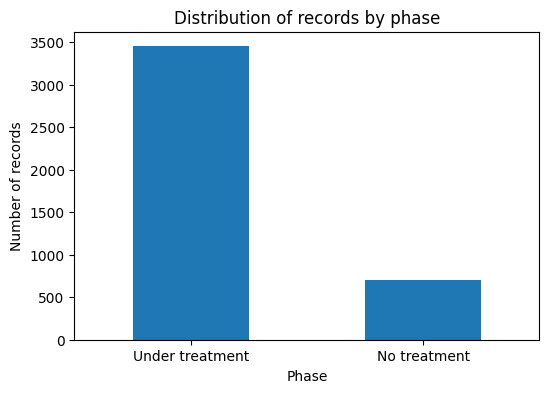

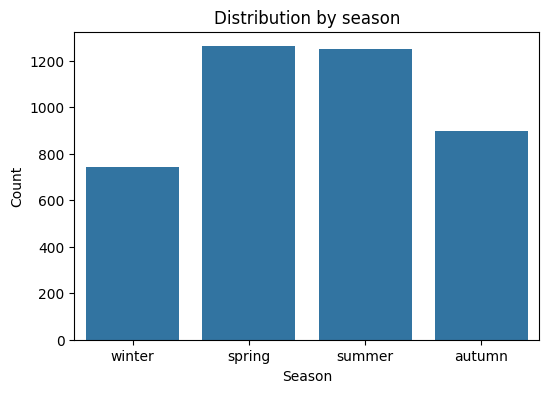

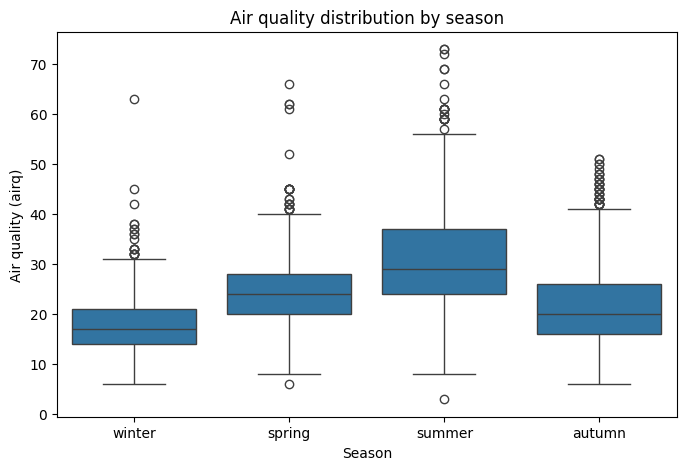

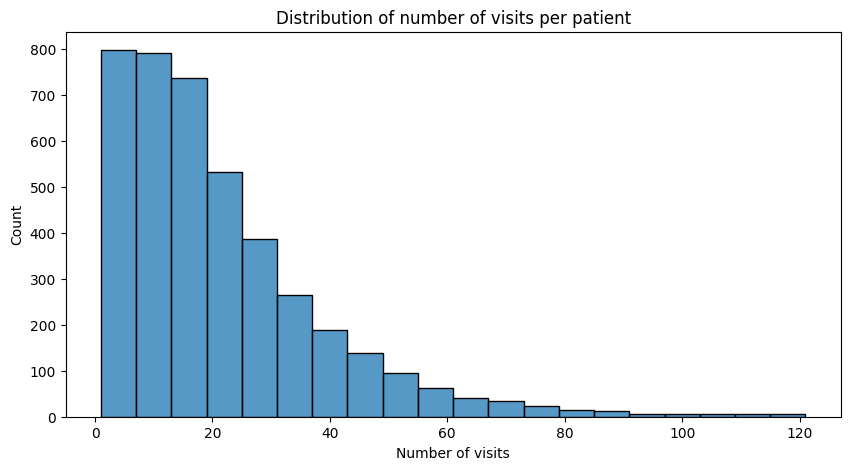

In [5]:
# Visualizations
fig = plot_phase_distribution(df)
fig.savefig("../reports/figures/phase_distribution.png", dpi=300)

fig = plot_season_distribution(df)
fig.savefig("../reports/figures/season_distribution.png", dpi=300)

fig = plot_airq_by_season(df)
fig.savefig("../reports/figures/airq_by_season.png", dpi=300)

fig = plot_visits_distribution(df)
fig.savefig("../reports/figures/visits_distribution.png", dpi=300)

In [6]:
# Save final dataset
df.to_csv("../data/processed/final_migraine.csv", index=False)
df.shape

(4152, 26)